In [163]:
import random
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# -----------------------------
# Parameters
# -----------------------------
locations = ["AD", "ES", "SA", "SB", "HMRB", "HRIC", "TFDL", "KNA", "KNB", "ENA", "ENB", "ENC", "ENG", "ENF", "END"]

project_types = (
    ["Minor Renovation"] * 10
    + ["Major Renovation"] * 4
    + ["Dry Lab"] * 4
    + ["Wet Lab"] * 4
    + ["Classroom"] * 4
    + ["IT/AV"] * 1
    + ["Furniture"] * 1
)

complexity_levels = ["Low", "Medium", "High"]
complexity_weights = [0.2, 0.5, 0.3]

risk_levels = ["Low", "Medium", "High", "Critical"]
risk_weights = [0.2, 0.4, 0.3, 0.1]

# Cost ranges per sqm
cost_ranges = {
    "Minor Renovation": (200, 1000),
    "Major Renovation": (1000, 3000),
    "Dry Lab": (3000, 5000),
    "Wet Lab": (4000, 8000),
    "Classroom": (2000, 5000),
    "IT/AV": (1000, 2000),
    "Furniture": (1000, 2000),
}

# -----------------------------
# Helper functions
# -----------------------------
def random_start_date():
    start = datetime(2020, 1, 1)
    end = datetime(2025, 1, 1)
    delta = end - start
    return (start + timedelta(days=random.randint(0, delta.days))).date()

def random_area():
    r = random.random()
    if r < 0.35:  # 35% less than 50 sqm
        return random.randint(5, 50)
    elif r < 0.7:  # 35% between 50 and 100 sqm
        return random.randint(51, 100)
    elif r < 0.9:  # 20% between 100 and 400 sqm
        return random.randint(101, 400)
    else:  # 10% over 350 sqm
        return random.randint(401, 500)

def duration_days(area, complexity, risk):
    base = random.randint(60, 120)  # base starting point

    # area factor
    if area < 50:
        area_factor = 1.0
    elif area <= 350:
        area_factor = 1.5
    else:
        area_factor = 2.0

    # complexity factor
    comp_factor = {"Low": 1.0, "Medium": 1.5, "High": 2.0}[complexity]

    # risk factor
    risk_factor = {"Low": 1.0, "Medium": 1.2, "High": 1.5, "Critical": 2.0}[risk]

    dur = base * area_factor * comp_factor * risk_factor
    return int(min(max(dur, 90), 1095))  # clamp between 90 and 1095 days

def cost_budget(area, project_type, complexity, risk, location):
    low, high = cost_ranges[project_type]
    base_cost = random.randint(low, high)

    comp_factor = {"Low": 1.0, "Medium": 1.2, "High": 1.5}[complexity]
    risk_factor = {"Low": 1.0, "Medium": 1.1, "High": 1.25, "Critical": 1.5}[risk]
    loc_factor = 1.2 if location in ["ES", "SA", "SB", "HMRB"] else 1.0

    raw_cost = area * base_cost * comp_factor * risk_factor * loc_factor
    return int(round(raw_cost, -2))  # round to nearest $100

def actual_duration(duration, cost, complexity, risk, q75_cost):
    # random adjustment between -10% and +30%
    adj = random.uniform(-0.1, 0.3)

    # bias upward for high cost
    if cost > q75_cost:
        adj += 0.05

    # complexity bias
    if complexity == "Medium":
        adj += 0.05
    elif complexity == "High":
        adj += 0.1

    # risk bias
    if risk == "Medium":
        adj += 0.05
    elif risk == "High":
        adj += 0.1
    elif risk == "Critical":
        adj += 0.2

    return int(duration * (1 + adj))

def actual_cost(cost, complexity, risk, q75_cost):
    # random adjustment between -10% and +30%
    adj = random.uniform(-0.1, 0.3)

    # bias upward for high cost
    if cost > q75_cost:
        adj += 0.05

    # complexity bias
    if complexity == "Medium":
        adj += 0.05
    elif complexity == "High":
        adj += 0.1

    # risk bias
    if risk == "Medium":
        adj += 0.05
    elif risk == "High":
        adj += 0.1
    elif risk == "Critical":
        adj += 0.2

    raw_actual_cost = cost * (1 + adj)
    return int(round(raw_actual_cost, -2))  # round to nearest $100

# -----------------------------
# Generate dataset
# -----------------------------
rows = []
for i in range(1000):
    project_id = f"P{i+1:04d}"
    start_date = random_start_date()
    location = random.choice(locations)
    project_type = random.choice(project_types)
    complexity = random.choices(complexity_levels, weights=complexity_weights)[0]
    risk = random.choices(risk_levels, weights=risk_weights)[0]
    area = random_area()
    duration = duration_days(area, complexity, risk)
    cost = cost_budget(area, project_type, complexity, risk, location)

    rows.append([project_id, start_date, location, project_type, duration, complexity, risk, area, cost])

df = pd.DataFrame(
    rows,
    columns=[
        "Project_ID",
        "Start_Date",
        "Location",
        "Project_Type",
        "Duration_Days",
        "Complexity",
        "Risk_Level",
        "Area_sqm",
        "Cost_Budgeted",
    ],
)

# Quartile threshold for cost bias
q75_cost = df["Cost_Budgeted"].quantile(0.75)

# Add Actual_Duration and Actual_Cost
df["Actual_Duration"] = df.apply(
    lambda row: actual_duration(
        row["Duration_Days"], row["Cost_Budgeted"], row["Complexity"], row["Risk_Level"], q75_cost
    ),
    axis=1,
)

df["Actual_Cost"] = df.apply(
    lambda row: actual_cost(
        row["Cost_Budgeted"], row["Complexity"], row["Risk_Level"], q75_cost
    ),
    axis=1,
)

# Preview first 20 rows
print(df.head(20))


   Project_ID  Start_Date Location      Project_Type  Duration_Days  \
0       P0001  2023-09-22      ENA  Minor Renovation            403   
1       P0002  2023-11-12      KNA           Dry Lab            230   
2       P0003  2024-03-27      KNA           Dry Lab            294   
3       P0004  2023-05-03      ENG  Minor Renovation            367   
4       P0005  2024-08-03      ENC  Minor Renovation            373   
5       P0006  2021-03-20       ES  Major Renovation            135   
6       P0007  2022-10-02       AD  Major Renovation            159   
7       P0008  2021-07-06      ENF  Major Renovation            172   
8       P0009  2021-02-14      ENF           Dry Lab            178   
9       P0010  2022-07-10      KNA  Minor Renovation            306   
10      P0011  2024-12-21      ENG  Minor Renovation            186   
11      P0012  2022-05-26      ENB           Wet Lab            270   
12      P0013  2021-11-03      ENA           Dry Lab            360   
13    

In [167]:
max_budgeted_cost = df['Cost_Budgeted'].max()
max_actual_cost = df['Actual_Cost'].max()

print(f"Maximum Budgeted Cost: {max_budgeted_cost}")
print(f"Maximum Actual Cost: {max_actual_cost}")

Maximum Budgeted Cost: 7196600
Maximum Actual Cost: 9686900


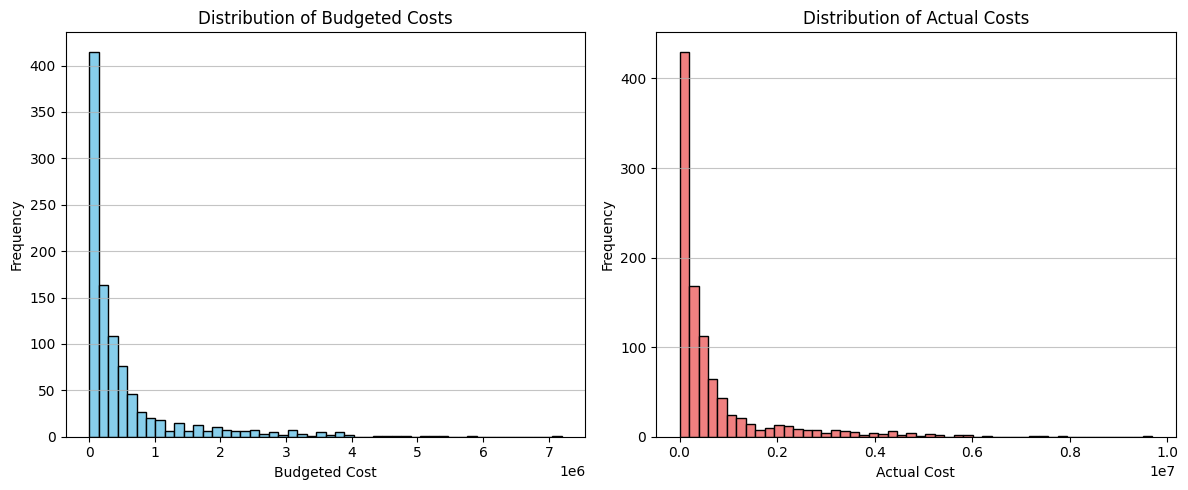

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Cost_Budgeted'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Budgeted Costs')
plt.xlabel('Budgeted Cost')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
plt.hist(df['Actual_Cost'], bins=50, color='lightcoral', edgecolor='black')
plt.title('Distribution of Actual Costs')
plt.xlabel('Actual Cost')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

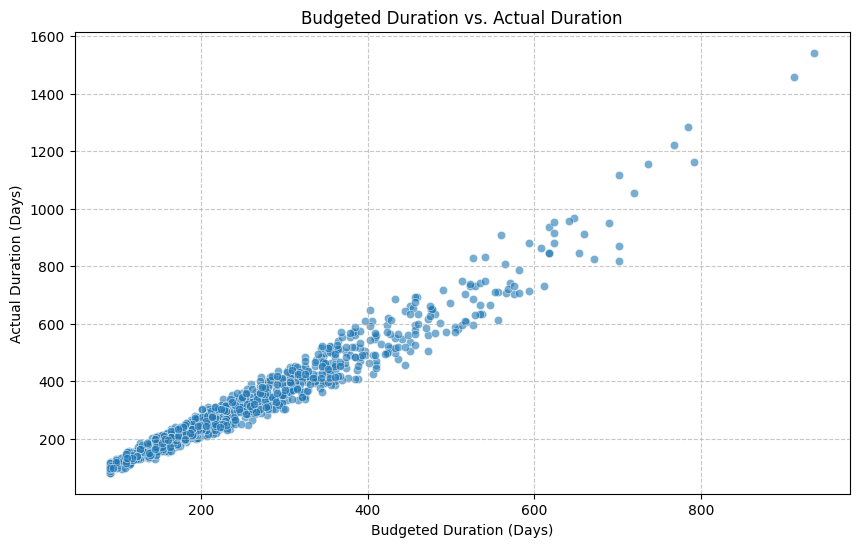

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Duration_Days', y='Actual_Duration', data=df, alpha=0.6)
plt.title('Budgeted Duration vs. Actual Duration')
plt.xlabel('Budgeted Duration (Days)')
plt.ylabel('Actual Duration (Days)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

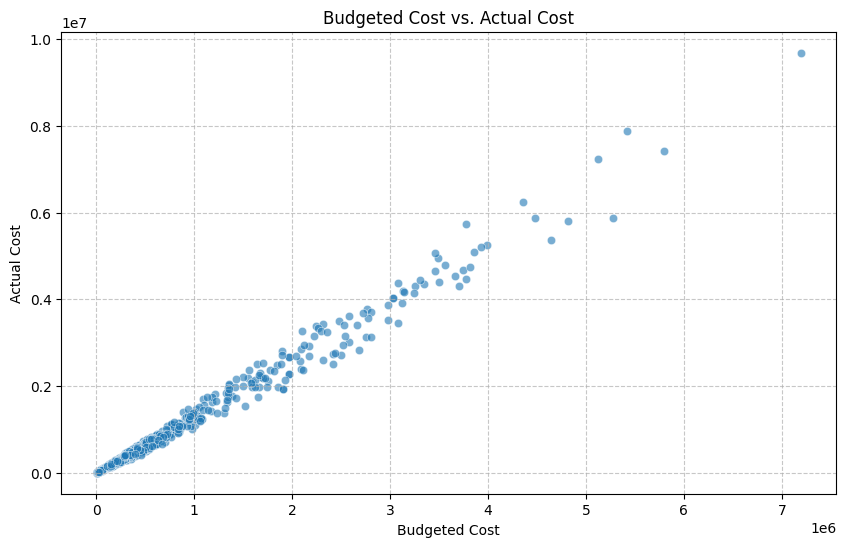

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cost_Budgeted', y='Actual_Cost', data=df, alpha=0.6)
plt.title('Budgeted Cost vs. Actual Cost')
plt.xlabel('Budgeted Cost')
plt.ylabel('Actual Cost')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

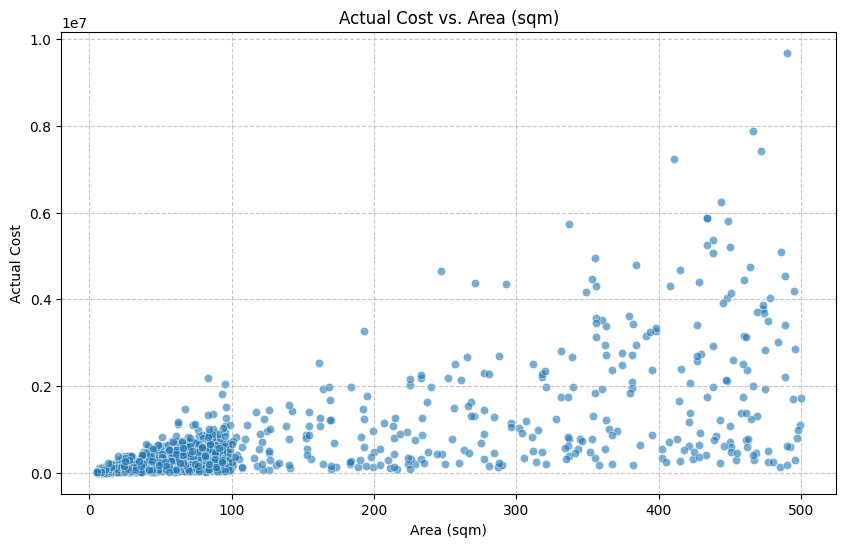

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area_sqm', y='Actual_Cost', data=df, alpha=0.6)
plt.title('Actual Cost vs. Area (sqm)')
plt.xlabel('Area (sqm)')
plt.ylabel('Actual Cost')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

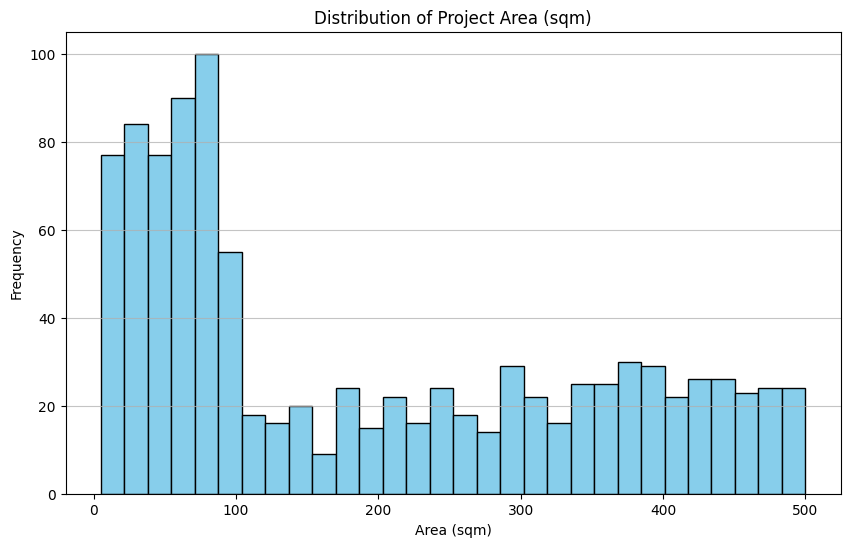

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Area_sqm'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Project Area (sqm)')
plt.xlabel('Area (sqm)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [168]:
#Save to CSV
df.to_csv("synthetic_projects.csv", index=False)